In [1]:
#!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yoanl\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [3]:
import pandas as pd
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz
import numpy as np # numerical python

%matplotlib inline
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv(r"C:\Users\yoanl\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3\amz_uk_price_prediction_dataset.csv")

In [5]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [10]:
df.shape

(2443651, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [12]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [6]:
num = df.select_dtypes(include="number")
cat = df.select_dtypes(exclude="number")

In [7]:
round(num.describe(),1)

,uid,stars,reviews,price,boughtInLastMonth
count,2443651.0,2443651.0,2443651.0,2443651.0,2443651.0
mean,1370545.3,2.2,480.6,89.2,25.9
std,816056.2,2.2,5944.1,345.6,240.5
min,1.0,0.0,0.0,0.0,0.0
25%,658921.5,0.0,0.0,10.0,0.0
50%,1349029.0,0.0,0.0,19.1,0.0
75%,2060685.5,4.4,59.0,46.0,0.0
max,2828593.0,5.0,1356658.0,100000.0,50000.0


In [8]:
cat.head()

,asin,title,isBestSeller,category
0,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",False,Hi-Fi Speakers
1,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",True,Hi-Fi Speakers
2,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",False,Hi-Fi Speakers
3,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",False,Hi-Fi Speakers
4,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,False,Hi-Fi Speakers


In [9]:
df.isna().sum()
missing = df.isna().sum()
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
spaced_values=df.eq(" ").sum()
spaced_values

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

***************************************************************************************

Part 1: Understanding Product Categories

In [12]:
frequency_table = cat.category.value_counts()
proportion_table = cat.category.value_counts(normalize=True).round(2)

In [51]:
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [13]:
proportion_table

category
Sports & Outdoors                         0.34
Beauty                                    0.01
Handmade Clothing, Shoes & Accessories    0.01
Bath & Body                               0.01
Birthday Gifts                            0.01
                                          ... 
Alexa Built-In Devices                    0.00
Motorbike Chassis                         0.00
Plugs                                     0.00
Smart Home Security & Lighting            0.00
Smart Speakers                            0.00
Name: proportion, Length: 296, dtype: float64

In [14]:
df2 = pd.concat([frequency_table, proportion_table], axis=1)
df2.columns = ['absolute_frequency', 'relative_frequency']
df2

,absolute_frequency,relative_frequency
category,,
Sports & Outdoors,836265,0.34
Beauty,19312,0.01
"Handmade Clothing, Shoes & Accessories",19229,0.01
Bath & Body,19092,0.01
Birthday Gifts,18978,0.01
...,...,...
Alexa Built-In Devices,107,0.00
Motorbike Chassis,107,0.00
Plugs,107,0.00


In [54]:
df2.head(10)

,category,absolute_frequency,relative_frequency
0,Sports & Outdoors,836265,0.34
1,Beauty,19312,0.01
2,"Handmade Clothing, Shoes & Accessories",19229,0.01
3,Bath & Body,19092,0.01
4,Birthday Gifts,18978,0.01
5,Manicure & Pedicure Products,18940,0.01
6,Skin Care,18769,0.01
7,Make-up,18756,0.01
8,Hair Care,18735,0.01
9,Fragrances,18564,0.01


the top 5 most listed product categories are:
- Sports & Outdoors
- Beauty
- Handmade Clothing, Shoes & Accessories
- Bath & Body
- Birthday Gifts

Sports & Outdoors dominates the list with 34% of the total

In [15]:
total_absolute = int(frequency_table.sum())
total_relative = int(proportion_table.sum())

In [16]:
total_absolute

2443651

In [17]:
df2 = df2.reset_index()

In [18]:
df2

,category,absolute_frequency,relative_frequency
0,Sports & Outdoors,836265,0.34
1,Beauty,19312,0.01
2,"Handmade Clothing, Shoes & Accessories",19229,0.01
3,Bath & Body,19092,0.01
4,Birthday Gifts,18978,0.01
...,...,...,...
291,Alexa Built-In Devices,107,0.00
292,Motorbike Chassis,107,0.00
293,Plugs,107,0.00
294,Smart Home Security & Lighting,104,0.00


C:\Users\yoanl\AppData\Local\Temp\ipykernel_13612\3335023170.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


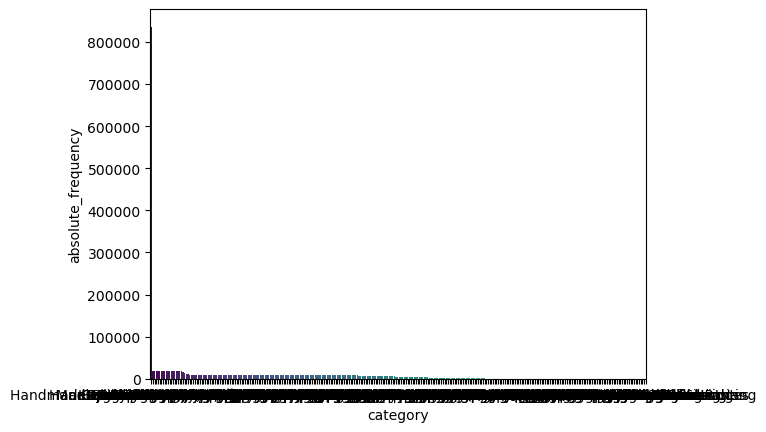

In [ ]:
sns.barplot(
    x="category",
    y='absolute_frequency',
    data=df2, 
    palette='viridis',
    legend=True,
)
plt.show()

C:\Users\yoanl\AppData\Local\Temp\ipykernel_4308\3978232328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


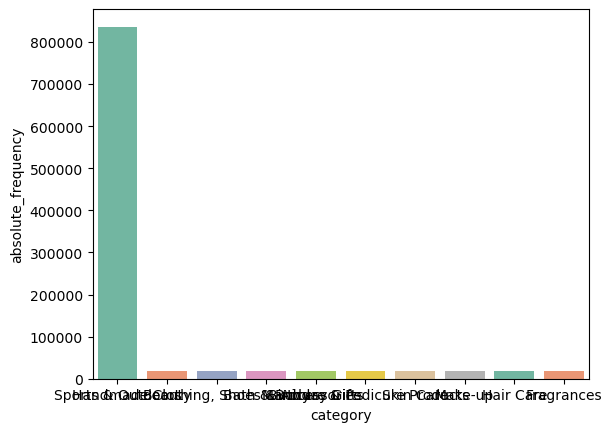

In [ ]:
#so many categories, so we selected just 10

dftop10 = df2.head(10)

sns.barplot(
    x="category",
    y='absolute_frequency',
    data=dftop10, 
    palette='Set2',
    legend=True,
)
plt.show()

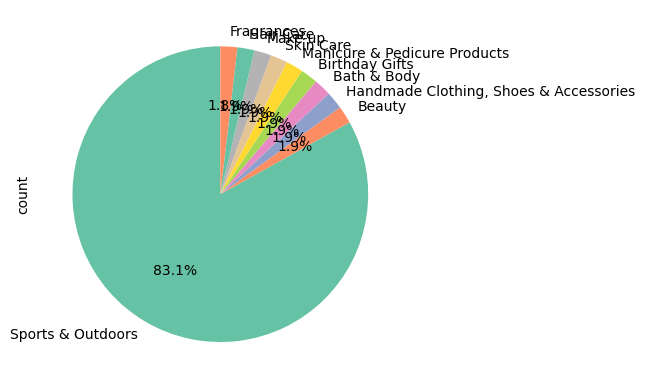

In [27]:
frequency_table[0:10].plot.pie(autopct='%1.1f%%' ,startangle=90, colors=sns.color_palette('Set2'))
plt.show()

the top 5 most listed product categories are:
- Sports & Outdoors
- Beauty
- Handmade Clothing, Shoes & Accessories
- Bath & Body
- Birthday Gifts

Sports & Outdoors dominates the list with 34% of the total

*************************************************************

Part 2: Delving into Product Pricing

In [55]:
round(num.price.describe(),2)

count    2443651.00
mean          89.24
std          345.61
min            0.00
25%            9.99
50%           19.09
75%           45.99
max       100000.00
Name: price, dtype: float64

In [ ]:
num.price.mode()

0    9.99
Name: price, dtype: float64

Mean = 89.24
Median = 19.09
Mode = 9.99

The average price point of product listed is 89.24.
The most common price point is 9.99.

insights: average is higher than mode and median, so long right tail, with outliers

In [53]:
round(float(num["price"].std()), 2)

345.61

In [54]:
round(float(num["price"].var()), 2)

119445.49

- **Dispersion**:
  - The variance, a measure of how far each sale price in the set is from the mean, is approximately \(119445.49\). A high variance implies that sale prices are widely dispersed.
  - The range of sale prices is 100,000, calculated as the difference between the maximum and minimum prices. This wide range underscores the diversity in property prices within the dataset.
  - 75% = only 45.99.

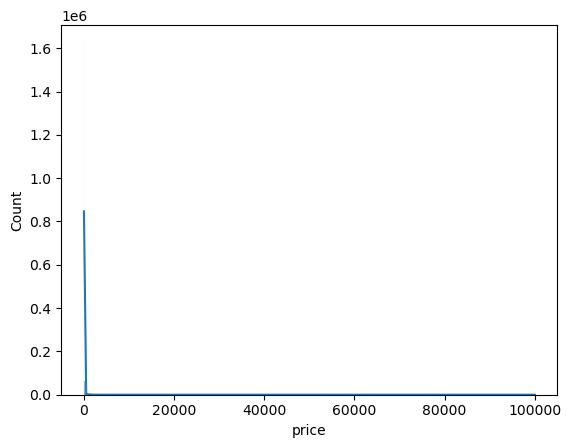

In [56]:
sns.histplot(num.price, bins="auto",kde=True)
plt.show()

no readability because of outliers

opcion 1:
fixed range

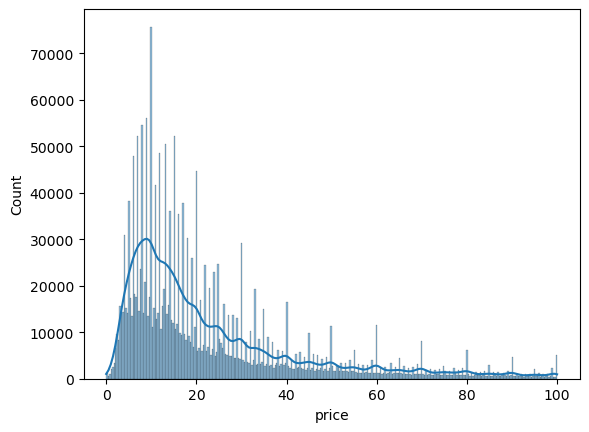

In [73]:
price_filtered = num.price[num.price <= 100]

sns.histplot(price_filtered, bins="auto", kde=True)
plt.show()

opcion 2: percentile 90

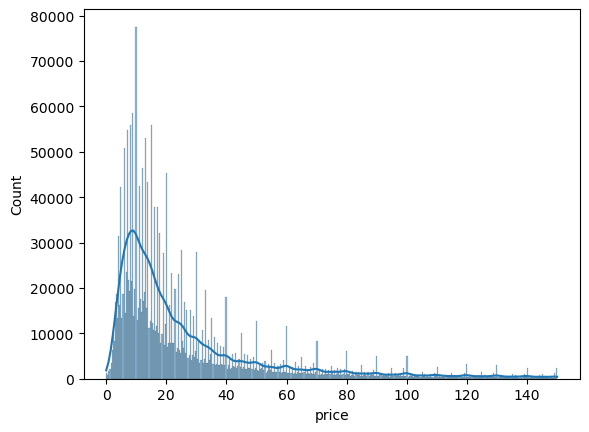

In [76]:
p90 = num.price.quantile(0.90)

sns.histplot(
    num[num.price <= p90]["price"],
    bins="auto",
    kde=True
)
plt.show()

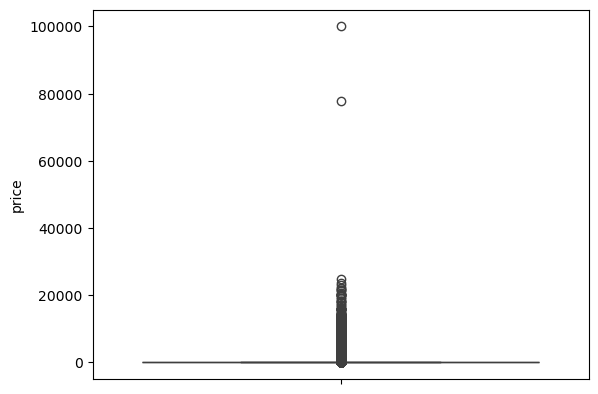

In [81]:
sns.boxplot(y="price", data=num);

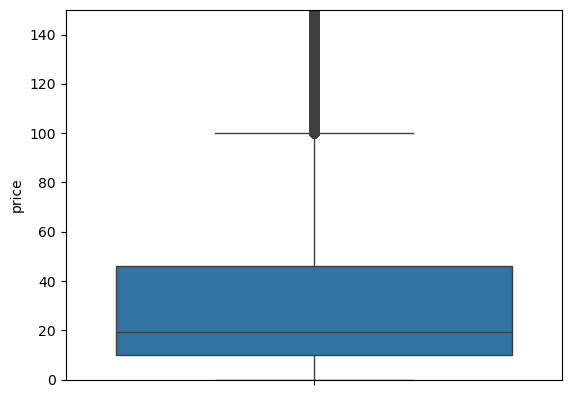

In [84]:
lim = num["price"].quantile(0.90)

sns.boxplot(y="price", data=num)
plt.ylim(0, lim)
plt.show()

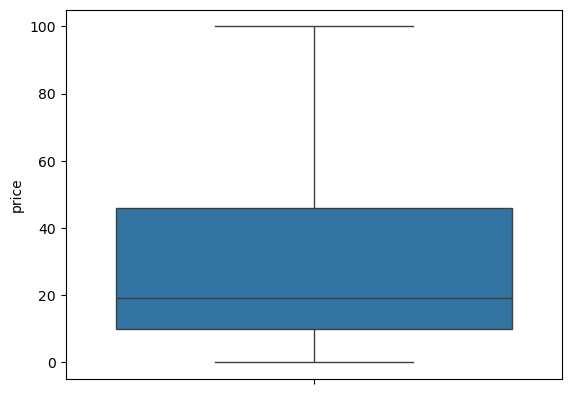

In [85]:
sns.boxplot(y="price", data=num, showfliers=False)
plt.show()

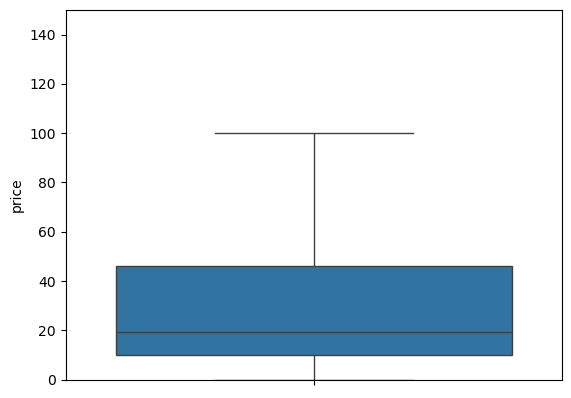

In [86]:
lim = num["price"].quantile(0.90)

sns.boxplot(y="price", data=num, showfliers=False)
plt.ylim(0, lim)
plt.show()

**********************

Part 3: Unpacking Product Ratings

In [87]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [89]:
num.stars

0          4.7
1          4.7
2          4.7
3          4.7
4          4.6
          ... 
2443646    0.0
2443647    0.0
2443648    0.0
2443649    4.3
2443650    4.5
Name: stars, Length: 2443651, dtype: float64

In [97]:
round(num.stars.describe(),2)

count    2443651.00
mean           2.15
std            2.19
min            0.00
25%            0.00
50%            0.00
75%            4.40
max            5.00
Name: stars, dtype: float64

In [98]:
num.stars.mode()

0    0.0
Name: stars, dtype: float64

In [99]:
num.reviews.describe()

count    2.443651e+06
mean     4.806278e+02
std      5.944124e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.900000e+01
max      1.356658e+06
Name: reviews, dtype: float64

50% products without reviews. so we filter products with reviews.

In [103]:
condition = (num["reviews"] != 0 )
num_withreviews = num[condition]
num_withreviews.describe()


,uid,stars,reviews,price,boughtInLastMonth
count,1.218010e+06,1.218010e+06,1.218010e+06,1.218010e+06,1.218010e+06
mean,1.397794e+06,4.319161e+00,9.642667e+02,4.531353e+01,5.181928e+01
std,8.420525e+05,5.552868e-01,8.391678e+03,1.288102e+02,3.384423e+02
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,6.905842e+05,4.100000e+00,9.000000e+00,8.990000e+00,0.000000e+00
50%,1.390506e+06,4.400000e+00,6.000000e+01,1.697000e+01,0.000000e+00
75%,2.126020e+06,4.600000e+00,3.600000e+02,3.485000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.999000e+04,5.000000e+04


In [104]:
num_withreviews.stars.mode()

0    4.5
Name: stars, dtype: float64

the average is 4.3 stars
median 4.4 stars
mode 4.5

customers usually rate products when they are satisfied.

In [105]:
round(float(num_withreviews["stars"].std()), 2)

0.56

In [106]:
round(float(num_withreviews["stars"].var()), 2)

0.31

In [108]:
IQR = 4.6-4.1
IQR

0.5

In [109]:
0.56/4.3

0.1302325581395349

the ratings are consistent. there is low dispersion. std/mean<20%.
mean similar to median and mode. std = 0.56 and var = 0.31.
IQR = 0.5, low range.

In [111]:
num_withreviews.stars.skew()

np.float64(-2.379568112212799)

skewness < 0. the distribution is negatively skewed (left-skewed)
loger tail on left side. the bulk of the data is concentrated on the right side.

In [112]:
num_withreviews.stars.kurt()

np.float64(9.78193769066435)

kurtosis = 9.8. heavy tails.
after seeing skewness != 0 and kurtosis != 0, the stars are not normally distributed. they lean towards higher values (4.3-4.5)

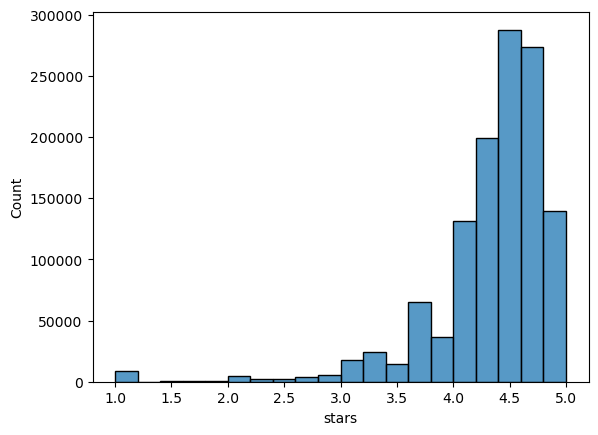

In [116]:
sns.histplot(num_withreviews.stars, bins= 20)
plt.show()

as we mentioned before, here in this histogram we can see that ratings concentrate in 4.3-4.6